# Capacità

Questo notebook presenta una esercitazione finalizzata a comprendere e studiare come funziona l'adattamento di modelli di regressione. In particolare lo scopo ultimo è quello di confrontare diversi modelli di regressione polinomiale del tipo:
$$y = \beta_0+ \beta_1x+ \dots + \beta_p x^p + \epsilon$$
L'esercizio finale prevede di far variare il grado del polinomio $p$, effettuando per ciascun grado 20 run di addestramento. Si vuole inoltre che per ogni run si ripeta la procedura di splitting ex-novo; infine si dovrà creare un grafico che mostrerà l'andamento di $\text{MSE}_{train}$ ed $\text{MSE}_{test}$ al variare del grado del polinomio, per osservare quale sia la **capacità ottima del modello**. 

In questo contesto la capacità di un modello indica la sua *abilità di adattarsi a funzioni più o meno complesse*. La capacità è direttamente controllata dal grado del polinomio, perché al crescere di $p$ il modello diventa più flessibile, ma può anche rischiare l'**overfitting**. 

Quindi la capacità ottima è quel valore di $p$ che bilancia meglio questi due estremi ed è osservabile graficamente nel punto in cui $\text{MSE}_{test}$ è minimo, cioé quando il modello generalizza meglio su dati nuovi.

Questo concetto è strettamente legato al **trade-off tra bias e varianza**, perché aumentare la capacità del modello significa ridurre il bias ma aumentare la varianza, o viceversa.

Si ricorda che in generale l'MSE corrisponde a:
$$\text{MSE} = \frac{1}{n}\sum_{i=1}^n(y_i-\hat{y}_i)^2$$
Naturalmente se si usano i valori target del training set o del test set si hanno le due versioni dell'MSE sopra citate.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dd = pd.read_csv('data/function_1000_25.csv')
dd

,X,y
0,1.872701,2.783879
1,4.753572,-2.698304
2,3.659970,-1.690942
3,2.993292,-0.404486
4,0.780093,0.497187
...,...,...
995,0.457910,0.184149
996,4.586568,-3.267441
997,0.684093,0.563941
998,4.751187,-2.698495


## 01. Analisi Esplorativa

In [ ]:
dd.shape # 1000 osservazioni, 2 variabili (X, y)

(1000, 2)

In [6]:
dd.describe()

,X,y
count,1000.000000,1000.000000
mean,2.451283,-0.445433
std,1.460687,1.599497
min,0.023160,-5.166565
25%,1.179866,-1.811375
50%,2.484037,-0.187648
75%,3.721598,0.866719
max,4.998588,3.570495


In [ ]:
dd.isna().mean() # Non ci sono NA

X    0.0
y    0.0
dtype: float64

<Axes: xlabel='X', ylabel='y'>

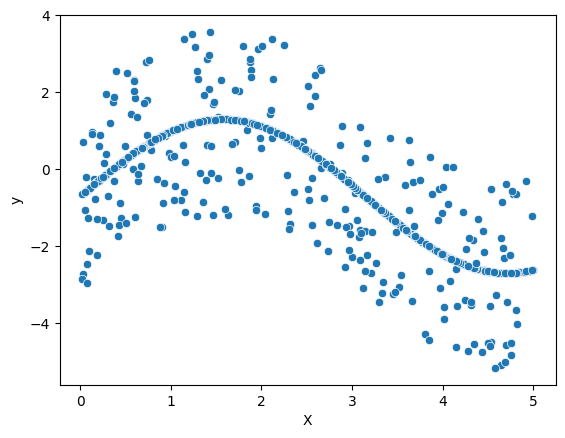

In [ ]:
# Rappresentazione grafica scatterplot
sns.scatterplot(x='X', y='y', data = dd)

La rappresentazione rispecchia quanto descritto nel testo dell'esercitazione: i dati descrivono una sinusoide, ma parte di essi sono stati corrotti da rumore gaussiano. 

Prima di effettuare l'addestramento del modello è di fondamentale importanza rimuovere valori anomali, perché questi distorcono i coefficienti $\beta$, soprattutto al crescere del grado del polinomio, che ne aumenta l'instabilità. 

## Rimozione degli outlier

Viene chiesto di rimuovere gli outlier con il metodo Local Outlier Factor; prima di eseguirlo però, vediamo rapidamente in cosa consiste:

Il **Local Outlier Factor** (LOF) è un algoritmo di rilevamento degli outlier basato sulla *densità locale di ogni punto rispetto ai suoi vicini*: questa tecnica non individua quindi valori estremi in assoluto, ma relativi ai punti prossimi.  

LOF confronta la densità di un punto con la densità dei suoi vicini:
- Se un punto si trova in una zona molto meno densa rispetto ai suoi vicini $\rightarrow$ è un outlier;

In termini semplici, per ogni punto $x$, LOF calcola uno score che misura quanto la sua densità locale sia anomala rispetto a quella dei suoi $k$ vicini; se lo score è $\approx 1$ allora non si è davanti ad outlier, altrimenti  se lo score è  $>1$ quel punto è possibilmente un outlier.

Questo algoritmo va regolato principalmente usando due parametri che sono quelli relativi al numero di vicini $k$ che devono essere considerati per ciascun punto, facendo attenzione ad evitare $k$ troppo piccoli (sensibile a variazioni molto locali) o troppo alti (anomalie rispetto all'andamento globale, poco sensibile); l'altro parametro è quello relativo al **livello di contaminazione**, cioé la proporzione attesa di outlier nel dataset e serve a dire quanti punti ci si aspetta che siano outlier: in questo caso il 25%.

In [12]:
# Outlier detection con LOF (Local Outlier Factor)
from sklearn.neighbors import LocalOutlierFactor
lof = LocalOutlierFactor(n_neighbors = 50, contamination = 0.25)
dd['outlier'] = lof.fit_predict(dd[['X', 'y']])
dd['outlier'] = dd['outlier'].map({1: 'inlier', -1: 'outlier'})

<Axes: xlabel='X', ylabel='y'>

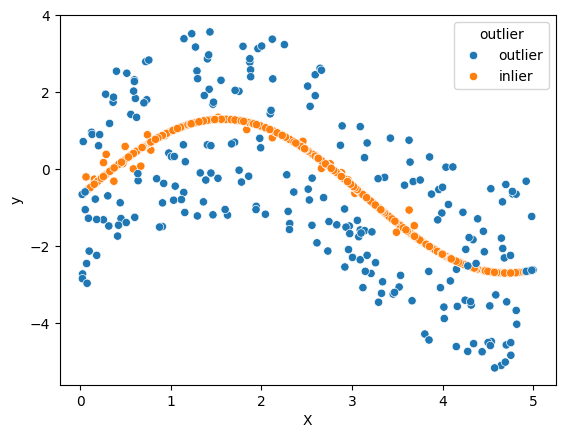

In [13]:
# Rappresentazione grafica con colorazione degli outlier
sns.scatterplot(x='X', y='y', hue = 'outlier', data = dd)